In [61]:
import pandas as pd

In [62]:
folderPath = "/mnt/d/Personal project/DeepLearning/nnForGraphs/attackClassifier/UNSW-NB15/"

In [63]:
dataDF = pd.read_csv(f"{folderPath}UNSW-NB15_1_cleaned_encoded.csv")

In [64]:
dataDF.head()

,Unnamed: 0,srcip,dstip,sport,dsport,proto,state,dur,sbytes,dbytes,Spkts,Dpkts,Sload,Dload,sttl,dttl,Label
0,0,59.166.0.0,149.171.126.6,1390.0,53.0,120,2,0.001055,132,164,2,2,500473.93750,621800.93750,31,29,0
1,1,59.166.0.0,149.171.126.9,33661.0,1024.0,120,2,0.036133,528,304,4,4,87676.08594,50480.17188,31,29,0
2,2,59.166.0.6,149.171.126.7,1464.0,53.0,120,2,0.001119,146,178,2,2,521894.53130,636282.37500,31,29,0
3,3,59.166.0.5,149.171.126.5,3593.0,53.0,120,2,0.001209,132,164,2,2,436724.56250,542597.18750,31,29,0
4,4,59.166.0.3,149.171.126.0,49664.0,53.0,120,2,0.001169,146,178,2,2,499572.25000,609067.56250,31,29,0


In [65]:
dataDF.drop(columns=["Unnamed: 0"] , inplace=True)

In [66]:
import networkx as netx

graph = netx.MultiDiGraph()

In [67]:
src = dataDF['srcip'].to_list()
dest = dataDF['dstip'].to_list()

In [68]:
graph.add_nodes_from(src)
graph.add_nodes_from(dest)

In [69]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "cpu"
)
print(f"Using device: {device}")


Using device: cuda


In [70]:
from torch_geometric.utils import from_networkx

for _, row in dataDF.iterrows():
    graph.add_edge(
        row["srcip"],
        row["dstip"],
        sport=row["sport"],
        dsport=row["dsport"],
        proto=row["proto"],
        state=row["state"],
        dur=row["dur"],
        sbytes=row["sbytes"],
        dbytes=row["dbytes"],
        Label=row["Label"]
    )

data = from_networkx(graph).to(device)

In [71]:
edge_features = []
edge_labels = []

for _, _, attr in graph.edges(data=True):

    edge_features.append([
        attr["dur"],
        attr["sbytes"],
        attr["dbytes"],
        attr["sport"],
        attr["dsport"],
        attr["proto"],
        attr["state"]
    ])

    edge_labels.append(attr["Label"])

In [72]:
from sklearn.preprocessing import StandardScaler
scalerEdges = StandardScaler()
edge_features[:] = scalerEdges.fit_transform(edge_features)

In [73]:
data.edge_attr = torch.tensor(
    edge_features,
    dtype=torch.float
).to(device)

data.edge_label = torch.tensor(
    edge_labels,
    dtype=torch.long
).to(device)

In [74]:
from sklearn.model_selection import train_test_split

edge_indices = torch.arange(data.edge_index.size(1))

trainIndx, testIndx = train_test_split(
    edge_indices.cpu().numpy(),
    test_size=0.25,
    random_state=31,
    stratify=data.edge_label.cpu().numpy()
)

trainIndx = torch.tensor(trainIndx, dtype=torch.long)
testIndx = torch.tensor(testIndx, dtype=torch.long)

print("Train edges:", len(trainIndx))
print("Test edges:", len(testIndx))

Train edges: 180540
Test edges: 60180


In [75]:
trainDF = dataDF.iloc[trainIndx.cpu().numpy()]

In [76]:
import pandas as pd

src_features = trainDF.groupby("srcip").agg(
    out_degree=("srcip", "count"),
    avg_sbytes=("sbytes", "mean"),
    avg_spkts=("Spkts", "mean"),
    avg_sload=("Sload", "mean"),
    avg_sttl=("sttl", "mean"),
    avg_duration=("dur", "mean")
)

dst_features = trainDF.groupby("dstip").agg(
    in_degree=("dstip", "count"),
    avg_dbytes=("dbytes", "mean"),
    avg_dpkts=("Dpkts", "mean"),
    avg_dload=("Dload", "mean"),
    avg_dttl=("dttl", "mean")
)

In [77]:
src_features

,out_degree,avg_sbytes,avg_spkts,avg_sload,avg_sttl,avg_duration
srcip,,,,,,
10.40.170.2,217,47.059908,1.023041,1.413384e-01,0.000000,1.382319
10.40.182.1,422,242.985782,4.336493,3.180431e+01,0.573460,39.590584
10.40.182.3,231,47.194805,1.025974,1.593341e-01,0.000000,1.558180
10.40.85.1,428,249.275701,4.355140,3.412567e+01,1.018692,24.943275
10.40.85.30,222,182.756757,3.972973,4.365776e+04,0.000000,30.155558
149.171.126.0,35,37408.657143,43.628571,2.579604e+06,29.171429,0.372589
149.171.126.1,46,73949.369565,62.760870,1.780455e+07,29.043478,0.692848
149.171.126.10,3,362.666667,4.666667,5.001221e+06,188.666667,0.198172
149.171.126.11,12,645.166667,3.166667,1.145798e+08,236.000000,0.424282


In [78]:
dst_features

,in_degree,avg_dbytes,avg_dpkts,avg_dload,avg_dttl
dstip,,,,,
10.40.170.2,217,0.000000,0.000000,0.000000e+00,0.000000
10.40.182.3,411,45.328467,0.985401,4.698577e+00,0.000000
10.40.85.1,222,111.243243,3.972973,2.657429e+04,0.000000
10.40.85.30,181,100.895028,2.193370,1.084638e+01,0.000000
149.171.126.0,15889,45935.639688,53.696268,3.100175e+06,28.985650
149.171.126.1,15693,45900.746320,53.800484,3.076915e+06,28.977506
149.171.126.10,1468,5875.534060,11.912807,2.799446e+04,185.387602
149.171.126.11,1374,7777.188501,14.767103,4.164514e+04,200.183406
149.171.126.12,3603,6311.053011,7.469331,1.341969e+04,51.364141


In [79]:
node_features = src_features.join(dst_features, how="outer")
node_features = node_features.fillna(0)

In [80]:
for node, features in node_features.iterrows():
    if graph.has_node(node):
        graph.nodes[node].update(features.to_dict())

In [81]:
print(graph.nodes["59.166.0.0"])

{'out_degree': 15895.0, 'avg_sbytes': 4383.06234664989, 'avg_spkts': 40.54683862849953, 'avg_sload': 1043548.9709413376, 'avg_sttl': 31.001509908776345, 'avg_duration': 0.5433844532871973, 'in_degree': 49.0, 'avg_dbytes': 2088.4489795918366, 'avg_dpkts': 22.224489795918366, 'avg_dload': 311726.7136835102, 'avg_dttl': 25.979591836734695}


In [82]:
node_features.head()

,out_degree,avg_sbytes,avg_spkts,avg_sload,avg_sttl,avg_duration,in_degree,avg_dbytes,avg_dpkts,avg_dload,avg_dttl
10.40.170.2,217.0,47.059908,1.023041,0.141338,0.000000,1.382319,217.0,0.000000,0.000000,0.000000,0.0
10.40.182.1,422.0,242.985782,4.336493,31.804307,0.573460,39.590584,0.0,0.000000,0.000000,0.000000,0.0
10.40.182.3,231.0,47.194805,1.025974,0.159334,0.000000,1.558180,411.0,45.328467,0.985401,4.698577,0.0
10.40.85.1,428.0,249.275701,4.355140,34.125668,1.018692,24.943275,222.0,111.243243,3.972973,26574.290186,0.0
10.40.85.30,222.0,182.756757,3.972973,43657.763413,0.000000,30.155558,181.0,100.895028,2.193370,10.846380,0.0


In [83]:
# Add nodes with attributes
for node, features in node_features.iterrows():
    graph.add_node(node, **features.to_dict())


In [84]:
print("Nodes:", graph.number_of_nodes())
print("Edges:", graph.number_of_edges())

print("Average degree:",
      sum(dict(graph.degree()).values()) / graph.number_of_nodes())

print("Self loops:",
      netx.number_of_selfloops(graph))

print("Connected Components:",
      netx.number_weakly_connected_components(graph))

Nodes: 43
Edges: 240720
Average degree: 11196.279069767443
Self loops: 721
Connected Components: 4


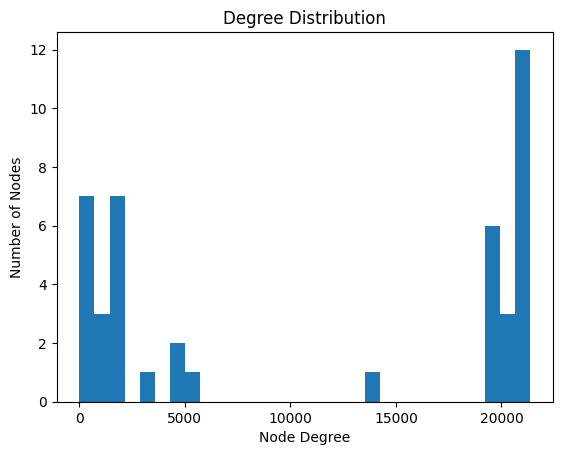

In [85]:
degrees = [d for _, d in graph.degree()]

import matplotlib.pyplot as plt

plt.hist(degrees, bins=30)
plt.xlabel("Node Degree")
plt.ylabel("Number of Nodes")
plt.title("Degree Distribution")
plt.show()

In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as funct
from torch_geometric.nn import GINEConv

In [87]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "cpu"
)
print(f"Using device: {device}")


Using device: cuda


In [88]:
print(data)

Data(edge_index=[2, 240720], sport=[240720], dsport=[240720], proto=[240720], state=[240720], dur=[240720], sbytes=[240720], dbytes=[240720], Label=[240720], num_nodes=43, edge_attr=[240720, 7], edge_label=[240720])


In [89]:
from sklearn.preprocessing import StandardScaler

scalerNode = StandardScaler()

node_features[:] = scalerNode.fit_transform(node_features)

data.x = torch.tensor(
    node_features.values,
    dtype=torch.float
)

In [90]:
class EdgeGCN(nn.Module):

    def __init__(self,node_feature_dim,edge_feature_dim,hidden_dim=64,embedding_dim=32):
        super().__init__()

        # GINE
        conv1NN = nn.Sequential(
            nn.Linear(node_feature_dim , hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim , hidden_dim)
        )
        conv2NN = nn.Sequential(
            nn.Linear(hidden_dim , hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim , embedding_dim)
        )
        self.conv1 = GINEConv(nn=conv1NN, edge_dim=edge_feature_dim)
        self.conv2 = GINEConv(nn=conv2NN, edge_dim=edge_feature_dim)

        # Edge Classifier
        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim * 2 + edge_feature_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self,x,edge_index,edge_attr):

        x = self.conv1(x, edge_index , edge_attr)
        x = funct.relu(x)

        x = self.conv2(x, edge_index , edge_attr)
        x = funct.relu(x)

        src = x[edge_index[0]]

        dst = x[edge_index[1]]

        edge_representation = torch.cat(

            [
                src,
                dst,
                edge_attr
            ],

            dim=1
        )

        out = self.classifier(edge_representation)

        return out

In [91]:
model = EdgeGCN(

    node_feature_dim=data.x.shape[1],

    edge_feature_dim=data.edge_attr.shape[1]

).to(device)

In [92]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001
)

criterion = nn.CrossEntropyLoss()

In [93]:
data = data.to(device)

In [94]:
epochs = 300

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    out = model(

        data.x,

        data.edge_index,

        data.edge_attr
    )

    loss = criterion(

        out[trainIndx],
        data.edge_label[trainIndx]
    )

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1:03d}"
        f" Loss : {loss.item():.4f}"
    )

Epoch 001 Loss : 2544.0276
Epoch 002 Loss : 4558.9136
Epoch 003 Loss : 265.8683
Epoch 004 Loss : 445.5372
Epoch 005 Loss : 911.1006
Epoch 006 Loss : 674.5723
Epoch 007 Loss : 480.3189
Epoch 008 Loss : 353.1268
Epoch 009 Loss : 275.4724
Epoch 010 Loss : 180.1563
Epoch 011 Loss : 83.1665
Epoch 012 Loss : 116.0875
Epoch 013 Loss : 197.5463
Epoch 014 Loss : 170.2827
Epoch 015 Loss : 52.9242
Epoch 016 Loss : 101.5466
Epoch 017 Loss : 126.9494
Epoch 018 Loss : 160.6198
Epoch 019 Loss : 162.6359
Epoch 020 Loss : 158.2541
Epoch 021 Loss : 129.9062
Epoch 022 Loss : 156.7950
Epoch 023 Loss : 189.1677
Epoch 024 Loss : 264.2671
Epoch 025 Loss : 303.7694
Epoch 026 Loss : 324.2965
Epoch 027 Loss : 324.0268
Epoch 028 Loss : 304.3206
Epoch 029 Loss : 266.9278
Epoch 030 Loss : 212.8524
Epoch 031 Loss : 187.7376
Epoch 032 Loss : 230.8373
Epoch 033 Loss : 216.6266
Epoch 034 Loss : 137.9006
Epoch 035 Loss : 76.2731
Epoch 036 Loss : 138.7365
Epoch 037 Loss : 191.1396
Epoch 038 Loss : 191.2274
Epoch 039 Los

In [95]:
model.eval()

with torch.no_grad():

    logits = model(

        data.x,

        data.edge_index,

        data.edge_attr
    )

    prediction = logits[testIndx].argmax(dim=1)


In [96]:
correct = (

    prediction == data.edge_label[testIndx]

).sum()

accuracy = correct / len(data.edge_label[testIndx])

print(
    accuracy.item()
)

0.9742106795310974


In [97]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(
    data.edge_label[testIndx].cpu(),
    prediction.cpu()
))

print(confusion_matrix(
    data.edge_label[testIndx].cpu(),
    prediction.cpu()
))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     54626
           1       0.79      0.97      0.87      5554

    accuracy                           0.97     60180
   macro avg       0.90      0.97      0.93     60180
weighted avg       0.98      0.97      0.98     60180

[[53221  1405]
 [  147  5407]]


In [98]:
out

tensor([[   795.9398,   -782.6462],
        [   796.0449,   -782.7595],
        [   795.9684,   -782.6595],
        ...,
        [ 29791.7070, -87203.2344],
        [ 29791.7070, -87203.2344],
        [ 11958.3027, -46490.3594]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [99]:
prob = torch.softmax(out[testIndx], dim=1)[:, 1]

print(
    roc_auc_score(
        data.edge_label[testIndx].detach().cpu().numpy(),
        prob.detach().cpu().numpy()
    )
)

0.9544591390506414
